In [1]:
# ============================================================
# CELL 1: Install required packages
# ============================================================

%pip install ultralytics --quiet
%pip install opencv-python-headless matplotlib seaborn --quiet

import ultralytics
ultralytics.checks()

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


In [2]:
# ============================================================
# CELL 2: Imports and global path configuration
# ============================================================

import os
import json
import shutil
import random
import xml.etree.ElementTree as xml_parser
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpl_patches
import seaborn as seaborn_plots
from PIL import Image

from ultralytics import YOLO

# ── Kaggle dataset root (adjust if your dataset path differs) ──
KAGGLE_DATASET_ROOT = Path("/kaggle/input/datasets/johannesbayer/cghd1152")

# ── Working directory where we'll build the YOLO folder structure ──
YOLO_DATASET_ROOT = Path("/kaggle/working/yolo_dataset")

# ── Where trained model artifacts will be saved ──
TRAINING_OUTPUT_ROOT = Path("/kaggle/working/runs")

# ── Reproducibility ──
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Dataset root : {KAGGLE_DATASET_ROOT}")
print(f"YOLO dataset : {YOLO_DATASET_ROOT}")
print(f"Training runs: {TRAINING_OUTPUT_ROOT}")

Dataset root : /kaggle/input/datasets/johannesbayer/cghd1152
YOLO dataset : /kaggle/working/yolo_dataset
Training runs: /kaggle/working/runs


In [3]:
# ============================================================
# CELL 3: Understand the raw dataset layout before converting
# ============================================================

def print_directory_tree(root_path: Path, max_depth: int = 3, current_depth: int = 0) -> None:
    """Recursively print a directory tree up to max_depth levels."""
    if current_depth > max_depth:
        return
    indent = "    " * current_depth
    print(f"{indent}{root_path.name}/")
    if root_path.is_dir():
        children = sorted(root_path.iterdir())
        for child in children[:6]:  # limit to 6 children per level for readability
            if child.is_dir():
                print_directory_tree(child, max_depth, current_depth + 1)
            else:
                print(f"{indent}    {child.name}")
        if len(children) > 6:
            print(f"{indent}    ... ({len(children) - 6} more)")

print_directory_tree(KAGGLE_DATASET_ROOT)

# ── Load classes.json which maps class names to integer IDs ──
classes_json_path = KAGGLE_DATASET_ROOT / "classes.json"
with open(classes_json_path, "r") as class_file:
    raw_class_data = json.load(class_file)

print("\n── classes.json content ──")
print(json.dumps(raw_class_data, indent=2))

cghd1152/
    README.md
    classes.json
    classes_color.json
    classes_discontinuous.json
    classes_ports.json
    consistency.py
    ... (38 more)

── classes.json content ──
{
  "__background__": 0,
  "text": 1,
  "junction": 2,
  "crossover": 3,
  "terminal": 4,
  "gnd": 5,
  "vss": 6,
  "voltage.dc": 7,
  "voltage.ac": 8,
  "voltage.battery": 9,
  "resistor": 10,
  "resistor.adjustable": 11,
  "resistor.photo": 12,
  "capacitor.unpolarized": 13,
  "capacitor.polarized": 14,
  "capacitor.adjustable": 15,
  "inductor": 16,
  "inductor.ferrite": 17,
  "inductor.coupled": 18,
  "transformer": 19,
  "diode": 20,
  "diode.light_emitting": 21,
  "diode.thyrector": 22,
  "diode.zener": 23,
  "diac": 24,
  "triac": 25,
  "thyristor": 26,
  "varistor": 27,
  "transistor.bjt": 28,
  "transistor.fet": 29,
  "transistor.photo": 30,
  "operational_amplifier": 31,
  "operational_amplifier.schmitt_trigger": 32,
  "optocoupler": 33,
  "integrated_circuit": 34,
  "integrated_circuit.ne555": 3

In [4]:
# ============================================================
# CELL 4: Build a clean class-name → integer-id mapping
# for use throughout the pipeline
# ============================================================

# classes.json from CGHD is a dict of {"ClassName": integer_id, ...}
# We sort by integer id to guarantee a stable ordered list
class_name_to_integer_id: dict[str, int] = raw_class_data

# Build the inverse mapping: integer id → class name
integer_id_to_class_name: dict[int, str] = {
    integer_id: class_name
    for class_name, integer_id in class_name_to_integer_id.items()
}

# Build an ordered list of class names (index = YOLO class index)
ordered_class_name_list: list[str] = [
    integer_id_to_class_name[key]
    for key in sorted(integer_id_to_class_name.keys())
]

total_number_of_classes = len(ordered_class_name_list)

print(f"Total classes: {total_number_of_classes}")
print("\nClass list (YOLO index → name):")
for yolo_index, class_name in enumerate(ordered_class_name_list):
    print(f"  [{yolo_index:>3}]  {class_name}")

Total classes: 62

Class list (YOLO index → name):
  [  0]  __background__
  [  1]  text
  [  2]  junction
  [  3]  crossover
  [  4]  terminal
  [  5]  gnd
  [  6]  vss
  [  7]  voltage.dc
  [  8]  voltage.ac
  [  9]  voltage.battery
  [ 10]  resistor
  [ 11]  resistor.adjustable
  [ 12]  resistor.photo
  [ 13]  capacitor.unpolarized
  [ 14]  capacitor.polarized
  [ 15]  capacitor.adjustable
  [ 16]  inductor
  [ 17]  inductor.ferrite
  [ 18]  inductor.coupled
  [ 19]  transformer
  [ 20]  diode
  [ 21]  diode.light_emitting
  [ 22]  diode.thyrector
  [ 23]  diode.zener
  [ 24]  diac
  [ 25]  triac
  [ 26]  thyristor
  [ 27]  varistor
  [ 28]  transistor.bjt
  [ 29]  transistor.fet
  [ 30]  transistor.photo
  [ 31]  operational_amplifier
  [ 32]  operational_amplifier.schmitt_trigger
  [ 33]  optocoupler
  [ 34]  integrated_circuit
  [ 35]  integrated_circuit.ne555
  [ 36]  integrated_circuit.voltage_regulator
  [ 37]  xor
  [ 38]  and
  [ 39]  or
  [ 40]  not
  [ 41]  nand
  [ 42]  n

In [5]:
# ============================================================
# CELL 5: Walk every drafter subfolder and collect
# paired (image_path, annotation_xml_path) tuples
# ============================================================

def find_all_image_annotation_pairs(dataset_root: Path) -> list[tuple[Path, Path]]:
    """
    Walk all drafter_D* subdirectories and return a list of
    (image_file_path, xml_annotation_path) pairs where both files exist.
    """
    paired_samples: list[tuple[Path, Path]] = []

    for drafter_directory in sorted(dataset_root.glob("drafter_*")):
        image_directory = drafter_directory / "images"
        annotation_directory = drafter_directory / "annotations"

        if not image_directory.exists() or not annotation_directory.exists():
            continue

        for image_file in sorted(image_directory.iterdir()):
            if image_file.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
                continue

            corresponding_xml = annotation_directory / (image_file.stem + ".xml")
            if corresponding_xml.exists():
                paired_samples.append((image_file, corresponding_xml))

    return paired_samples


all_paired_samples = find_all_image_annotation_pairs(KAGGLE_DATASET_ROOT)

print(f"Total paired (image, annotation) samples found: {len(all_paired_samples)}")
print("\nFirst 5 samples:")
for image_path, xml_path in all_paired_samples[:5]:
    print(f"  image : {image_path.relative_to(KAGGLE_DATASET_ROOT)}")
    print(f"  xml   : {xml_path.relative_to(KAGGLE_DATASET_ROOT)}")
    print()

Total paired (image, annotation) samples found: 3269

First 5 samples:
  image : drafter_-1/images/C-10_D1_P1.jpg
  xml   : drafter_-1/annotations/C-10_D1_P1.xml

  image : drafter_-1/images/C-10_D1_P2.jpg
  xml   : drafter_-1/annotations/C-10_D1_P2.xml

  image : drafter_-1/images/C-10_D1_P3.jpg
  xml   : drafter_-1/annotations/C-10_D1_P3.xml

  image : drafter_-1/images/C-10_D1_P4.jpg
  xml   : drafter_-1/annotations/C-10_D1_P4.xml

  image : drafter_-1/images/C-10_D1_P5.jpg
  xml   : drafter_-1/annotations/C-10_D1_P5.xml



Image     : C363_D2_P3.png
Dimensions: 5240 × 2603
Objects   : 18
  text                            xmin=1769 ymin=1655 xmax=1909 ymax=1819
  resistor                        xmin=1520 ymin=862 xmax=1728 ymax=1236
  text                            xmin=2634 ymin=101 xmax=2834 ymax=283
  text                            xmin=594 ymin=965 xmax=750 ymax=1162
  text                            xmin=3425 ymin=1022 xmax=3555 ymax=1244
  text                            xmin=2462 ymin=2168 xmax=2646 ymax=2354
  text                            xmin=1766 ymin=937 xmax=1968 ymax=1141
  junction                        xmin=352 ymin=2092 xmax=448 ymax=2190


/tmp/ipykernel_55/3320752280.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = plt.cm.get_cmap("tab20", total_number_of_classes)


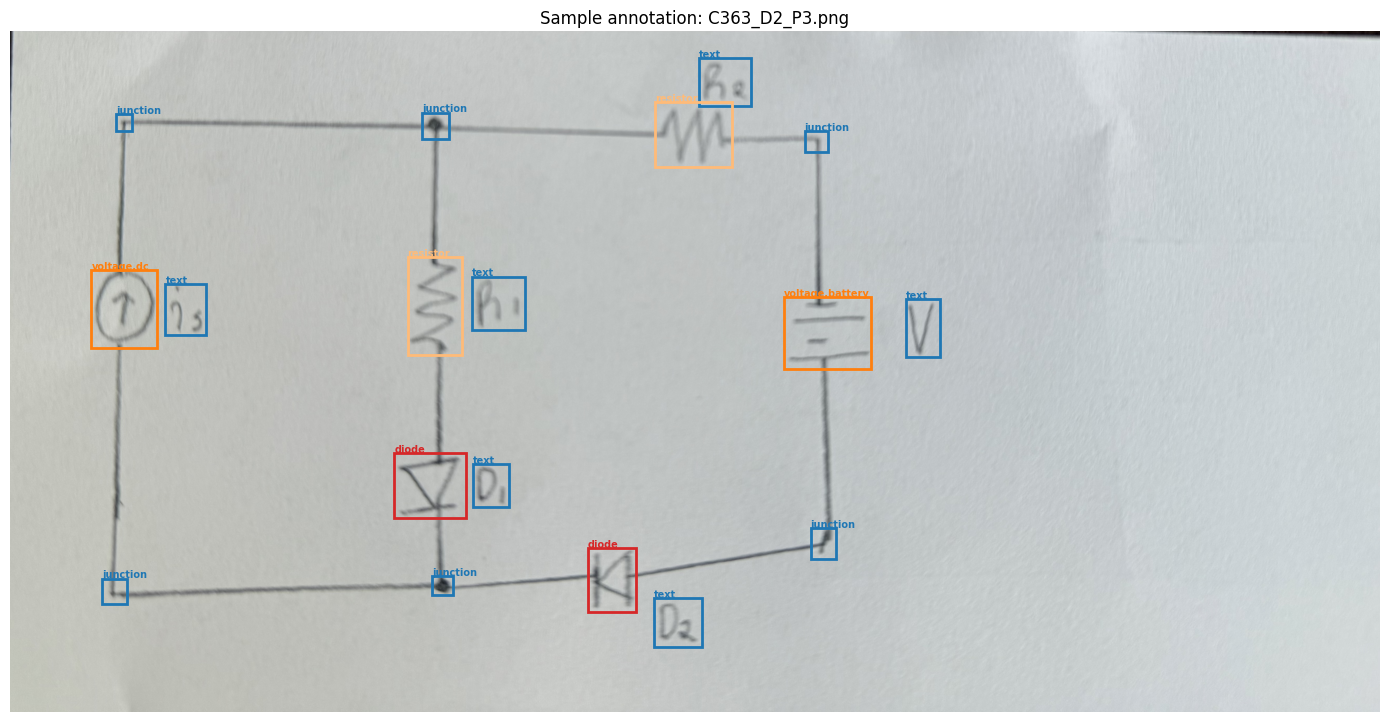

In [6]:
# ============================================================
# CELL 6: Parse a PASCAL VOC XML annotation file
# and display a sample image with its bounding boxes
# ============================================================

def parse_pascal_voc_xml(xml_file_path: Path) -> tuple[int, int, list[dict]]:
    """
    Parse a PASCAL VOC XML annotation file.

    Returns:
        image_width (int)
        image_height (int)
        list of dicts, each with keys:
            class_name (str), xmin (int), ymin (int), xmax (int), ymax (int)
    """
    tree = xml_parser.parse(xml_file_path)
    root_element = tree.getroot()

    size_element = root_element.find("size")
    image_width = int(size_element.find("width").text)
    image_height = int(size_element.find("height").text)

    bounding_box_list: list[dict] = []
    for object_element in root_element.findall("object"):
        class_name = object_element.find("name").text.strip()
        bndbox_element = object_element.find("bndbox")
        bounding_box_list.append({
            "class_name": class_name,
            "xmin": int(float(bndbox_element.find("xmin").text)),
            "ymin": int(float(bndbox_element.find("ymin").text)),
            "xmax": int(float(bndbox_element.find("xmax").text)),
            "ymax": int(float(bndbox_element.find("ymax").text)),
        })

    return image_width, image_height, bounding_box_list


# ── Preview a random sample ──
random_sample_image_path, random_sample_xml_path = random.choice(all_paired_samples)
sample_image_width, sample_image_height, sample_bounding_boxes = parse_pascal_voc_xml(
    random_sample_xml_path
)

print(f"Image     : {random_sample_image_path.name}")
print(f"Dimensions: {sample_image_width} × {sample_image_height}")
print(f"Objects   : {len(sample_bounding_boxes)}")
for box in sample_bounding_boxes[:8]:
    print(f"  {box['class_name']:30s}  xmin={box['xmin']} ymin={box['ymin']} "
          f"xmax={box['xmax']} ymax={box['ymax']}")

# ── Visualize ──
sample_image_bgr = cv2.imread(str(random_sample_image_path))
sample_image_rgb = cv2.cvtColor(sample_image_bgr, cv2.COLOR_BGR2RGB)

figure, axis = plt.subplots(1, 1, figsize=(14, 10))
axis.imshow(sample_image_rgb)

color_palette = plt.cm.get_cmap("tab20", total_number_of_classes)

for bounding_box in sample_bounding_boxes:
    class_yolo_index = class_name_to_integer_id.get(bounding_box["class_name"], 0)
    box_color = color_palette(class_yolo_index)
    box_width = bounding_box["xmax"] - bounding_box["xmin"]
    box_height = bounding_box["ymax"] - bounding_box["ymin"]
    rectangle = mpl_patches.Rectangle(
        (bounding_box["xmin"], bounding_box["ymin"]),
        box_width, box_height,
        linewidth=2, edgecolor=box_color, facecolor="none"
    )
    axis.add_patch(rectangle)
    axis.text(
        bounding_box["xmin"], bounding_box["ymin"] - 4,
        bounding_box["class_name"],
        color=box_color, fontsize=7, fontweight="bold"
    )

axis.set_title(f"Sample annotation: {random_sample_image_path.name}")
axis.axis("off")
plt.tight_layout()
plt.show()

Total annotated instances across dataset: 248020
Unique classes present: 59


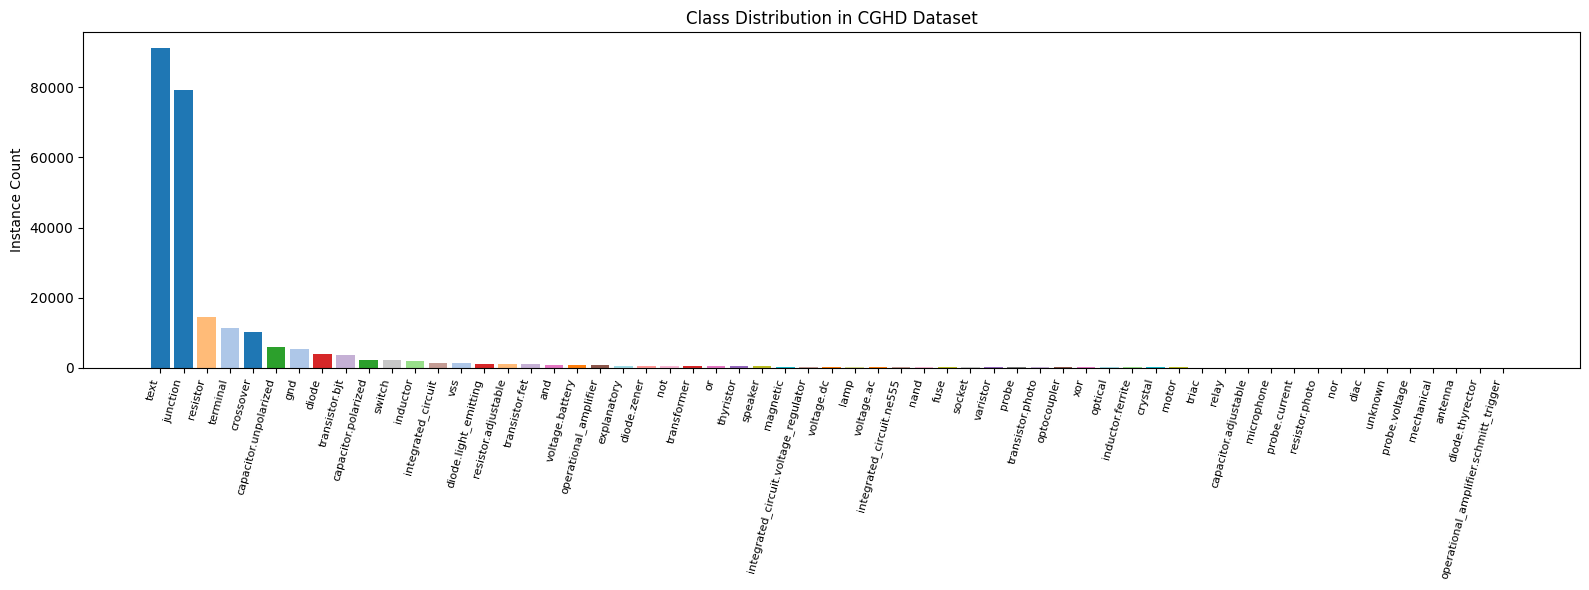

In [7]:
# ============================================================
# CELL 7: Count class frequencies across the entire dataset
# to understand imbalance before training
# ============================================================

from collections import Counter

class_instance_counter: Counter = Counter()

for _, xml_annotation_path in all_paired_samples:
    _, _, bounding_boxes = parse_pascal_voc_xml(xml_annotation_path)
    for bounding_box in bounding_boxes:
        class_instance_counter[bounding_box["class_name"]] += 1

total_annotated_instances = sum(class_instance_counter.values())
print(f"Total annotated instances across dataset: {total_annotated_instances}")
print(f"Unique classes present: {len(class_instance_counter)}")

# ── Bar chart ──
sorted_class_counts = class_instance_counter.most_common()
class_labels = [item[0] for item in sorted_class_counts]
class_counts = [item[1] for item in sorted_class_counts]

figure, axis = plt.subplots(figsize=(16, 6))
bar_colors = [color_palette(class_name_to_integer_id.get(name, 0)) for name in class_labels]
axis.bar(range(len(class_labels)), class_counts, color=bar_colors)
axis.set_xticks(range(len(class_labels)))
axis.set_xticklabels(class_labels, rotation=75, ha="right", fontsize=8)
axis.set_ylabel("Instance Count")
axis.set_title("Class Distribution in CGHD Dataset")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 8: Convert all PASCAL VOC annotations to YOLO format.
#
# YOLO format per line:
#   <class_index> <x_center_norm> <y_center_norm> <width_norm> <height_norm>
# All coordinates are normalized to [0, 1] relative to image dimensions.
# ============================================================

def convert_voc_bounding_box_to_yolo_format(
    xmin: int, ymin: int, xmax: int, ymax: int,
    image_width: int, image_height: int
) -> tuple[float, float, float, float]:
    """
    Convert absolute pixel bounding box to normalized YOLO format.

    Returns:
        (x_center_normalized, y_center_normalized,
         width_normalized, height_normalized)
    """
    x_center_normalized = ((xmin + xmax) / 2.0) / image_width
    y_center_normalized = ((ymin + ymax) / 2.0) / image_height
    width_normalized = (xmax - xmin) / image_width
    height_normalized = (ymax - ymin) / image_height
    return (
        x_center_normalized,
        y_center_normalized,
        width_normalized,
        height_normalized,
    )


def write_yolo_label_file(
    output_label_path: Path,
    image_width: int,
    image_height: int,
    bounding_boxes: list[dict],
    class_name_to_yolo_index: dict[str, int],
) -> None:
    """
    Write a YOLO-format .txt label file for one image.
    Skips any bounding box whose class name is not in the mapping.
    """
    label_lines: list[str] = []

    for bounding_box in bounding_boxes:
        class_name = bounding_box["class_name"]
        if class_name not in class_name_to_yolo_index:
            continue

        yolo_class_index = class_name_to_yolo_index[class_name]
        x_center, y_center, width, height = convert_voc_bounding_box_to_yolo_format(
            bounding_box["xmin"], bounding_box["ymin"],
            bounding_box["xmax"], bounding_box["ymax"],
            image_width, image_height,
        )
        label_lines.append(
            f"{yolo_class_index} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
        )

    output_label_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_label_path, "w") as label_file:
        label_file.write("\n".join(label_lines))


print("Conversion function defined. Run Cell 9 to execute the full conversion + split.")

Conversion function defined. Run Cell 9 to execute the full conversion + split.


In [9]:
# ============================================================
# CELL 9: Shuffle all samples, split 70/20/10 train/val/test,
# copy images and write YOLO label files into the standard
# YOLO directory tree:
#
#   yolo_dataset/
#     images/train/   images/val/   images/test/
#     labels/train/   labels/val/   labels/test/
# ============================================================

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.20
# Remainder automatically becomes test

shuffled_samples = all_paired_samples.copy()
random.shuffle(shuffled_samples)

total_samples = len(shuffled_samples)
train_end_index = int(total_samples * TRAIN_FRACTION)
validation_end_index = int(total_samples * (TRAIN_FRACTION + VALIDATION_FRACTION))

split_assignment: dict[str, list[tuple[Path, Path]]] = {
    "train": shuffled_samples[:train_end_index],
    "val":   shuffled_samples[train_end_index:validation_end_index],
    "test":  shuffled_samples[validation_end_index:],
}

for split_name, split_count in {k: len(v) for k, v in split_assignment.items()}.items():
    print(f"  {split_name:<6}: {split_count} samples")

# ── Create output directory structure ──
for split_name in split_assignment:
    (YOLO_DATASET_ROOT / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET_ROOT / "labels" / split_name).mkdir(parents=True, exist_ok=True)

# ── Copy images and write label files ──
conversion_error_count = 0

for split_name, sample_pairs in split_assignment.items():
    for image_source_path, xml_source_path in sample_pairs:
        try:
            image_width, image_height, bounding_boxes = parse_pascal_voc_xml(xml_source_path)
        except Exception as parse_error:
            print(f"  [WARN] Failed to parse {xml_source_path.name}: {parse_error}")
            conversion_error_count += 1
            continue

        destination_image_path = (
            YOLO_DATASET_ROOT / "images" / split_name / image_source_path.name
        )
        shutil.copy2(image_source_path, destination_image_path)

        destination_label_path = (
            YOLO_DATASET_ROOT / "labels" / split_name / (image_source_path.stem + ".txt")
        )
        write_yolo_label_file(
            destination_label_path,
            image_width,
            image_height,
            bounding_boxes,
            class_name_to_integer_id,
        )

print(f"\nConversion complete. Errors: {conversion_error_count}")
print(f"Output written to: {YOLO_DATASET_ROOT}")

  train : 2288 samples
  val   : 654 samples
  test  : 327 samples

Conversion complete. Errors: 0
Output written to: /kaggle/working/yolo_dataset


In [10]:
# ============================================================
# CELL 10: Write the dataset.yaml file that YOLO reads
# to know where data lives and what the class names are
# ============================================================

yaml_class_names_block = "\n".join(
    f"  {index}: {name}"
    for index, name in enumerate(ordered_class_name_list)
)

dataset_yaml_content = f"""# CGHD1152 - Handwritten Electrical Schematic Dataset
path: {YOLO_DATASET_ROOT}
train: images/train
val: images/val
test: images/test

nc: {total_number_of_classes}
names:
{yaml_class_names_block}
"""

dataset_yaml_path = YOLO_DATASET_ROOT / "dataset.yaml"
with open(dataset_yaml_path, "w") as yaml_file:
    yaml_file.write(dataset_yaml_content)

print(f"dataset.yaml written to: {dataset_yaml_path}")
print("\n── Preview ──")
print(dataset_yaml_content[:600])

dataset.yaml written to: /kaggle/working/yolo_dataset/dataset.yaml

── Preview ──
# CGHD1152 - Handwritten Electrical Schematic Dataset
path: /kaggle/working/yolo_dataset
train: images/train
val: images/val
test: images/test

nc: 62
names:
  0: __background__
  1: text
  2: junction
  3: crossover
  4: terminal
  5: gnd
  6: vss
  7: voltage.dc
  8: voltage.ac
  9: voltage.battery
  10: resistor
  11: resistor.adjustable
  12: resistor.photo
  13: capacitor.unpolarized
  14: capacitor.polarized
  15: capacitor.adjustable
  16: inductor
  17: inductor.ferrite
  18: inductor.coupled
  19: transformer
  20: diode
  21: diode.light_emitting
  22: diode.thyrector
  23: diode.zen


/tmp/ipykernel_55/778707264.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab20", len(class_names))


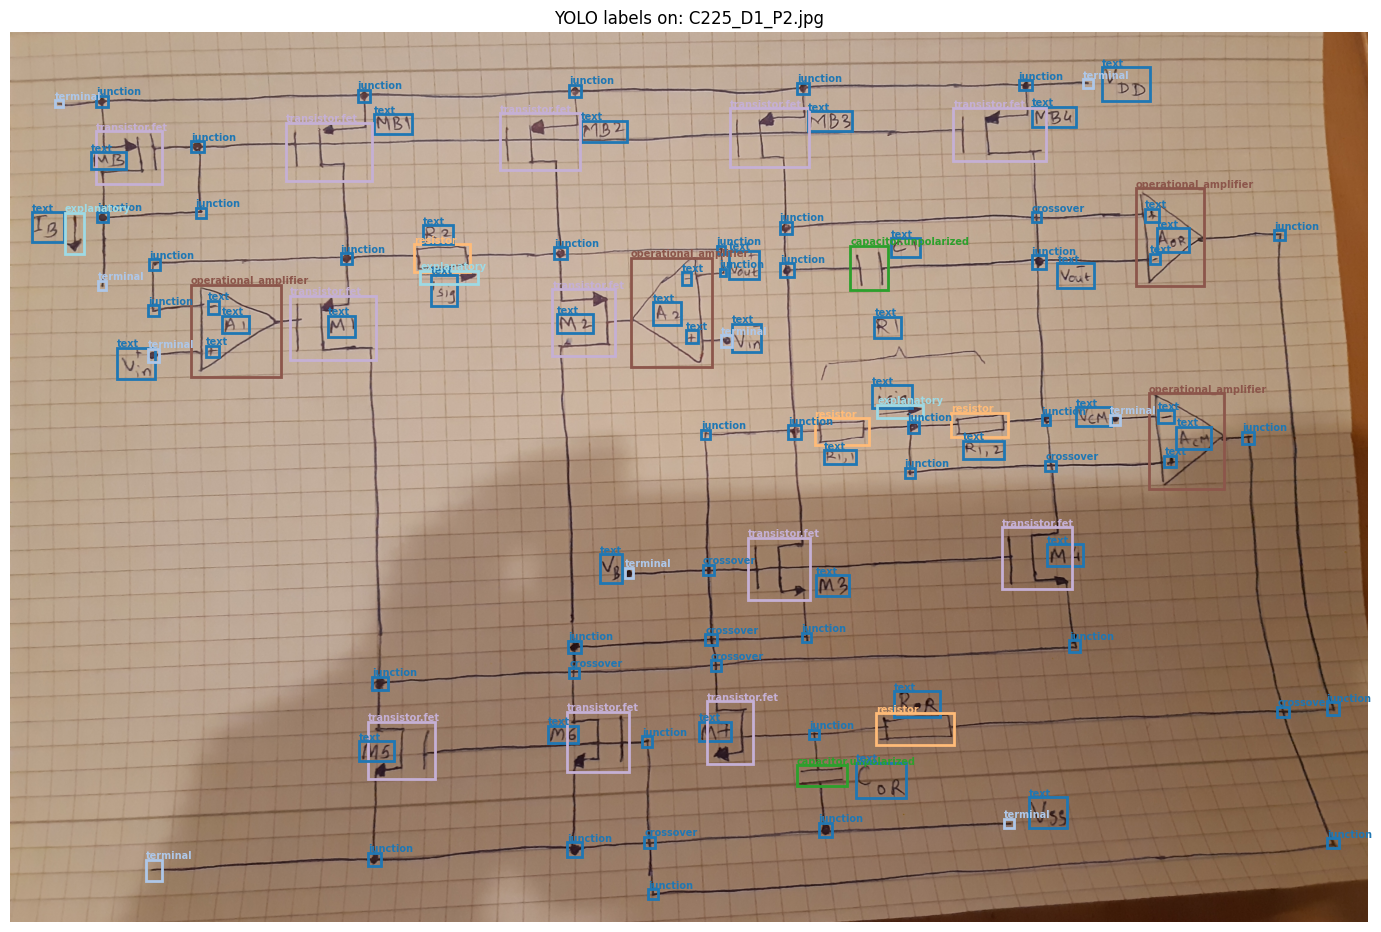

In [11]:
# ============================================================
# CELL 11: Sanity-check the conversion by re-drawing boxes
# from the YOLO .txt label on the copied image
# ============================================================

def draw_yolo_labels_on_image(
    image_file_path: Path,
    label_file_path: Path,
    class_names: list[str],
) -> np.ndarray:
    """
    Load an image and overlay its YOLO-format bounding box labels.
    Returns an RGB numpy array.
    """
    image_bgr = cv2.imread(str(image_file_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_height_pixels, image_width_pixels = image_rgb.shape[:2]

    if not label_file_path.exists():
        return image_rgb

    with open(label_file_path, "r") as label_file:
        label_lines = label_file.read().strip().splitlines()

    palette = plt.cm.get_cmap("tab20", len(class_names))

    figure, axis = plt.subplots(figsize=(14, 10))
    axis.imshow(image_rgb)

    for label_line in label_lines:
        parts = label_line.strip().split()
        if len(parts) != 5:
            continue
        yolo_class_index = int(parts[0])
        x_center_norm = float(parts[1])
        y_center_norm = float(parts[2])
        width_norm = float(parts[3])
        height_norm = float(parts[4])

        box_width_pixels = width_norm * image_width_pixels
        box_height_pixels = height_norm * image_height_pixels
        xmin_pixel = (x_center_norm * image_width_pixels) - (box_width_pixels / 2)
        ymin_pixel = (y_center_norm * image_height_pixels) - (box_height_pixels / 2)

        box_color = palette(yolo_class_index)
        rectangle = mpl_patches.Rectangle(
            (xmin_pixel, ymin_pixel), box_width_pixels, box_height_pixels,
            linewidth=2, edgecolor=box_color, facecolor="none"
        )
        axis.add_patch(rectangle)
        class_label = class_names[yolo_class_index] if yolo_class_index < len(class_names) else str(yolo_class_index)
        axis.text(xmin_pixel, ymin_pixel - 4, class_label,
                  color=box_color, fontsize=7, fontweight="bold")

    axis.axis("off")
    axis.set_title(f"YOLO labels on: {image_file_path.name}")
    plt.tight_layout()
    plt.show()


# ── Pick a random train image and verify ──
random_train_image = random.choice(
    list((YOLO_DATASET_ROOT / "images" / "train").iterdir())
)
corresponding_label = (
    YOLO_DATASET_ROOT / "labels" / "train" / (random_train_image.stem + ".txt")
)

draw_yolo_labels_on_image(random_train_image, corresponding_label, ordered_class_name_list)

In [12]:
# ============================================================
# CELL 12: Train a YOLOv8m model (medium — good balance of
# speed and accuracy on Kaggle P100/T4 GPUs).
#
# Adjust IMAGE_SIZE and BATCH_SIZE to fit GPU memory:
#   16GB GPU  → batch=16, imgsz=640
#    8GB GPU  → batch=8,  imgsz=640
# ============================================================

PRETRAINED_MODEL_CHECKPOINT = "yolov8m.pt"   # nano=yolov8n, small=yolov8s, medium=yolov8m
TRAINING_IMAGE_SIZE = 640
TRAINING_BATCH_SIZE = 16
NUMBER_OF_EPOCHS = 80
PATIENCE_EPOCHS = 20    # early stopping if no improvement

yolo_model = YOLO(PRETRAINED_MODEL_CHECKPOINT)

training_results = yolo_model.train(
    data=str(dataset_yaml_path),
    epochs=NUMBER_OF_EPOCHS,
    imgsz=TRAINING_IMAGE_SIZE,
    batch=TRAINING_BATCH_SIZE,
    patience=PATIENCE_EPOCHS,
    device=0,                          # GPU 0
    project=str(TRAINING_OUTPUT_ROOT),
    name="cghd_yolov8m",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    augment=True,
    hsv_h=0.015,
    hsv_s=0.2,
    hsv_v=0.3,
    degrees=10.0,
    translate=0.1,
    scale=0.3,
    fliplr=0.5,
    mosaic=1.0,
    verbose=True,
    seed=RANDOM_SEED,
)

print("Training complete.")
print(f"Best weights saved to: {training_results.save_dir}/weights/best.pt")

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.2, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cghd_yolov8m, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patienc

Columns in results.csv:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


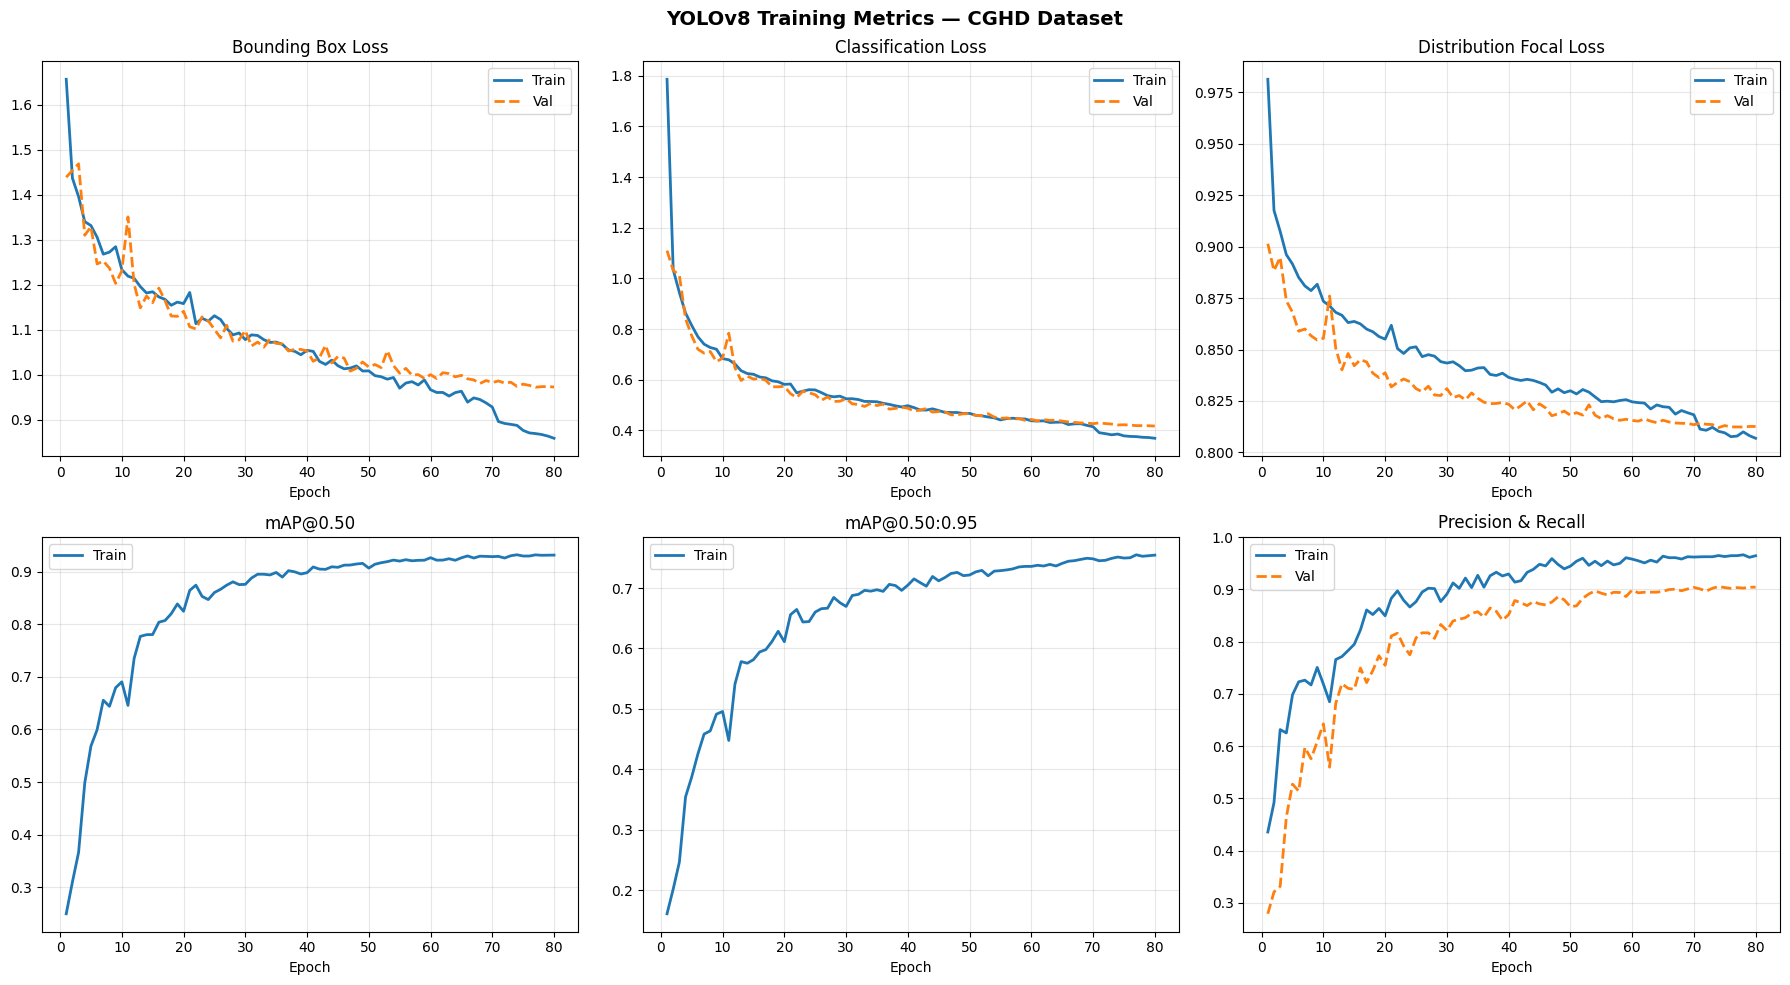

In [13]:
# ============================================================
# CELL 13: Load and plot the training metrics CSV
# produced by Ultralytics during training
# ============================================================

import pandas as pd

training_run_directory = Path(training_results.save_dir)
metrics_csv_path = training_run_directory / "results.csv"

metrics_dataframe = pd.read_csv(metrics_csv_path)
metrics_dataframe.columns = metrics_dataframe.columns.str.strip()

print("Columns in results.csv:")
print(list(metrics_dataframe.columns))

figure, axes = plt.subplots(2, 3, figsize=(18, 10))
figure.suptitle("YOLOv8 Training Metrics — CGHD Dataset", fontsize=14, fontweight="bold")

metric_column_pairs = [
    ("train/box_loss",  "val/box_loss",  "Bounding Box Loss",     axes[0, 0]),
    ("train/cls_loss",  "val/cls_loss",  "Classification Loss",   axes[0, 1]),
    ("train/dfl_loss",  "val/dfl_loss",  "Distribution Focal Loss", axes[0, 2]),
    ("metrics/mAP50(B)", None,           "mAP@0.50",              axes[1, 0]),
    ("metrics/mAP50-95(B)", None,        "mAP@0.50:0.95",         axes[1, 1]),
    ("metrics/precision(B)", "metrics/recall(B)", "Precision & Recall", axes[1, 2]),
]

epochs_array = metrics_dataframe["epoch"].values

for train_column, val_column, chart_title, chart_axis in metric_column_pairs:
    if train_column in metrics_dataframe.columns:
        chart_axis.plot(epochs_array, metrics_dataframe[train_column], label="Train", linewidth=2)
    if val_column and val_column in metrics_dataframe.columns:
        chart_axis.plot(epochs_array, metrics_dataframe[val_column], label="Val", linewidth=2, linestyle="--")
    chart_axis.set_title(chart_title)
    chart_axis.set_xlabel("Epoch")
    chart_axis.legend()
    chart_axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# CELL 14: Run formal evaluation (mAP, precision, recall)
# on the held-out test split using the best saved weights
# ============================================================

best_weights_path = training_run_directory / "weights" / "best.pt"
evaluation_model = YOLO(str(best_weights_path))

test_evaluation_metrics = evaluation_model.val(
    data=str(dataset_yaml_path),
    split="test",
    imgsz=TRAINING_IMAGE_SIZE,
    batch=8,
    device=0,
    verbose=True,
)

print("\n── Test Set Evaluation Summary ──")
print(f"  mAP@0.50       : {test_evaluation_metrics.box.map50:.4f}")
print(f"  mAP@0.50:0.95  : {test_evaluation_metrics.box.map:.4f}")
print(f"  Precision      : {test_evaluation_metrics.box.mp:.4f}")
print(f"  Recall         : {test_evaluation_metrics.box.mr:.4f}")

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,875,658 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3098.8±875.2 MB/s, size: 1669.0 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/test... 327 images, 0 backgrounds, 15 corrupt: 100% ━━━━━━━━━━━━ 327/327 177.2it/s 1.8s0.0s
val: /kaggle/working/yolo_dataset/images/test/C-10_D1_P3.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [      1.835       2.333       1.799       3.384       1.838       1.522       3.369       1.533      1.7615      2.6025       2.599      2.2485       3.535       1.738       2.313       1.243      1.3835        2.03       1.829       1.721       1.284       1.368       2.778        1.43       1.243       2.778
       1.833       3.088       1.417       1.728       1.834       2.016       2.301       3.536       1.365       3.105       1.504       3.113       1.385  

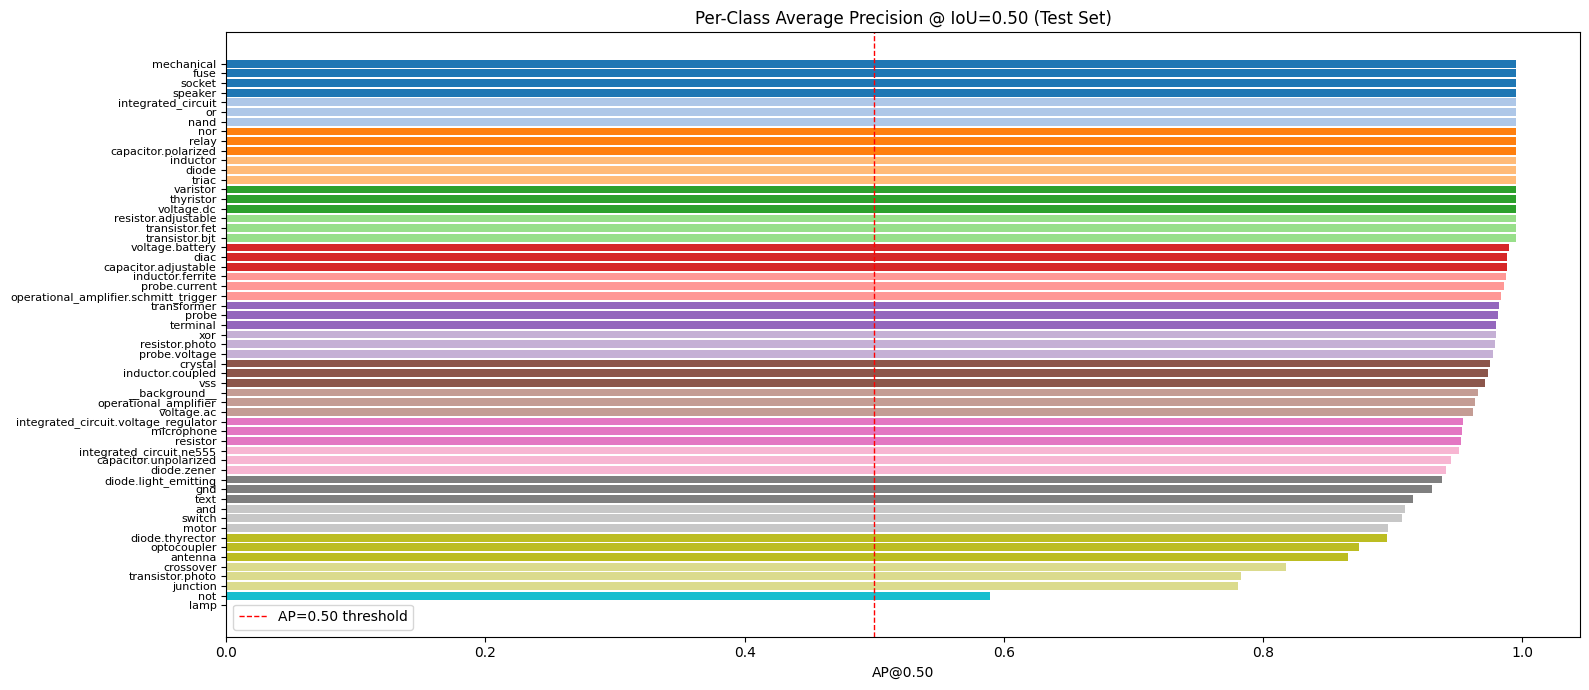


Bottom 5 classes (most room for improvement):
  crossover                            AP50=0.8179
  transistor.photo                     AP50=0.7830
  junction                             AP50=0.7805
  not                                  AP50=0.5894
  lamp                                 AP50=0.0000


In [15]:
# ============================================================
# CELL 15: Per-class mAP@0.50 to identify which components
# are well-detected vs. which need more data/tuning
# ============================================================

per_class_ap50_values = test_evaluation_metrics.box.ap50  # shape: (num_classes,)
per_class_names = test_evaluation_metrics.names            # dict: {index: name}

sorted_class_indices = np.argsort(per_class_ap50_values)[::-1]
sorted_class_names  = [per_class_names[i] for i in sorted_class_indices]
sorted_ap50_values  = per_class_ap50_values[sorted_class_indices]

figure, axis = plt.subplots(figsize=(16, 7))
bar_colors = [color_palette(i / total_number_of_classes) for i in range(len(sorted_class_names))]
bars = axis.barh(range(len(sorted_class_names)), sorted_ap50_values, color=bar_colors)
axis.set_yticks(range(len(sorted_class_names)))
axis.set_yticklabels(sorted_class_names, fontsize=8)
axis.set_xlabel("AP@0.50")
axis.set_title("Per-Class Average Precision @ IoU=0.50 (Test Set)")
axis.axvline(x=0.5, color="red", linestyle="--", linewidth=1, label="AP=0.50 threshold")
axis.legend()
axis.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nBottom 5 classes (most room for improvement):")
for name, ap in zip(sorted_class_names[-5:], sorted_ap50_values[-5:]):
    print(f"  {name:<35}  AP50={ap:.4f}")

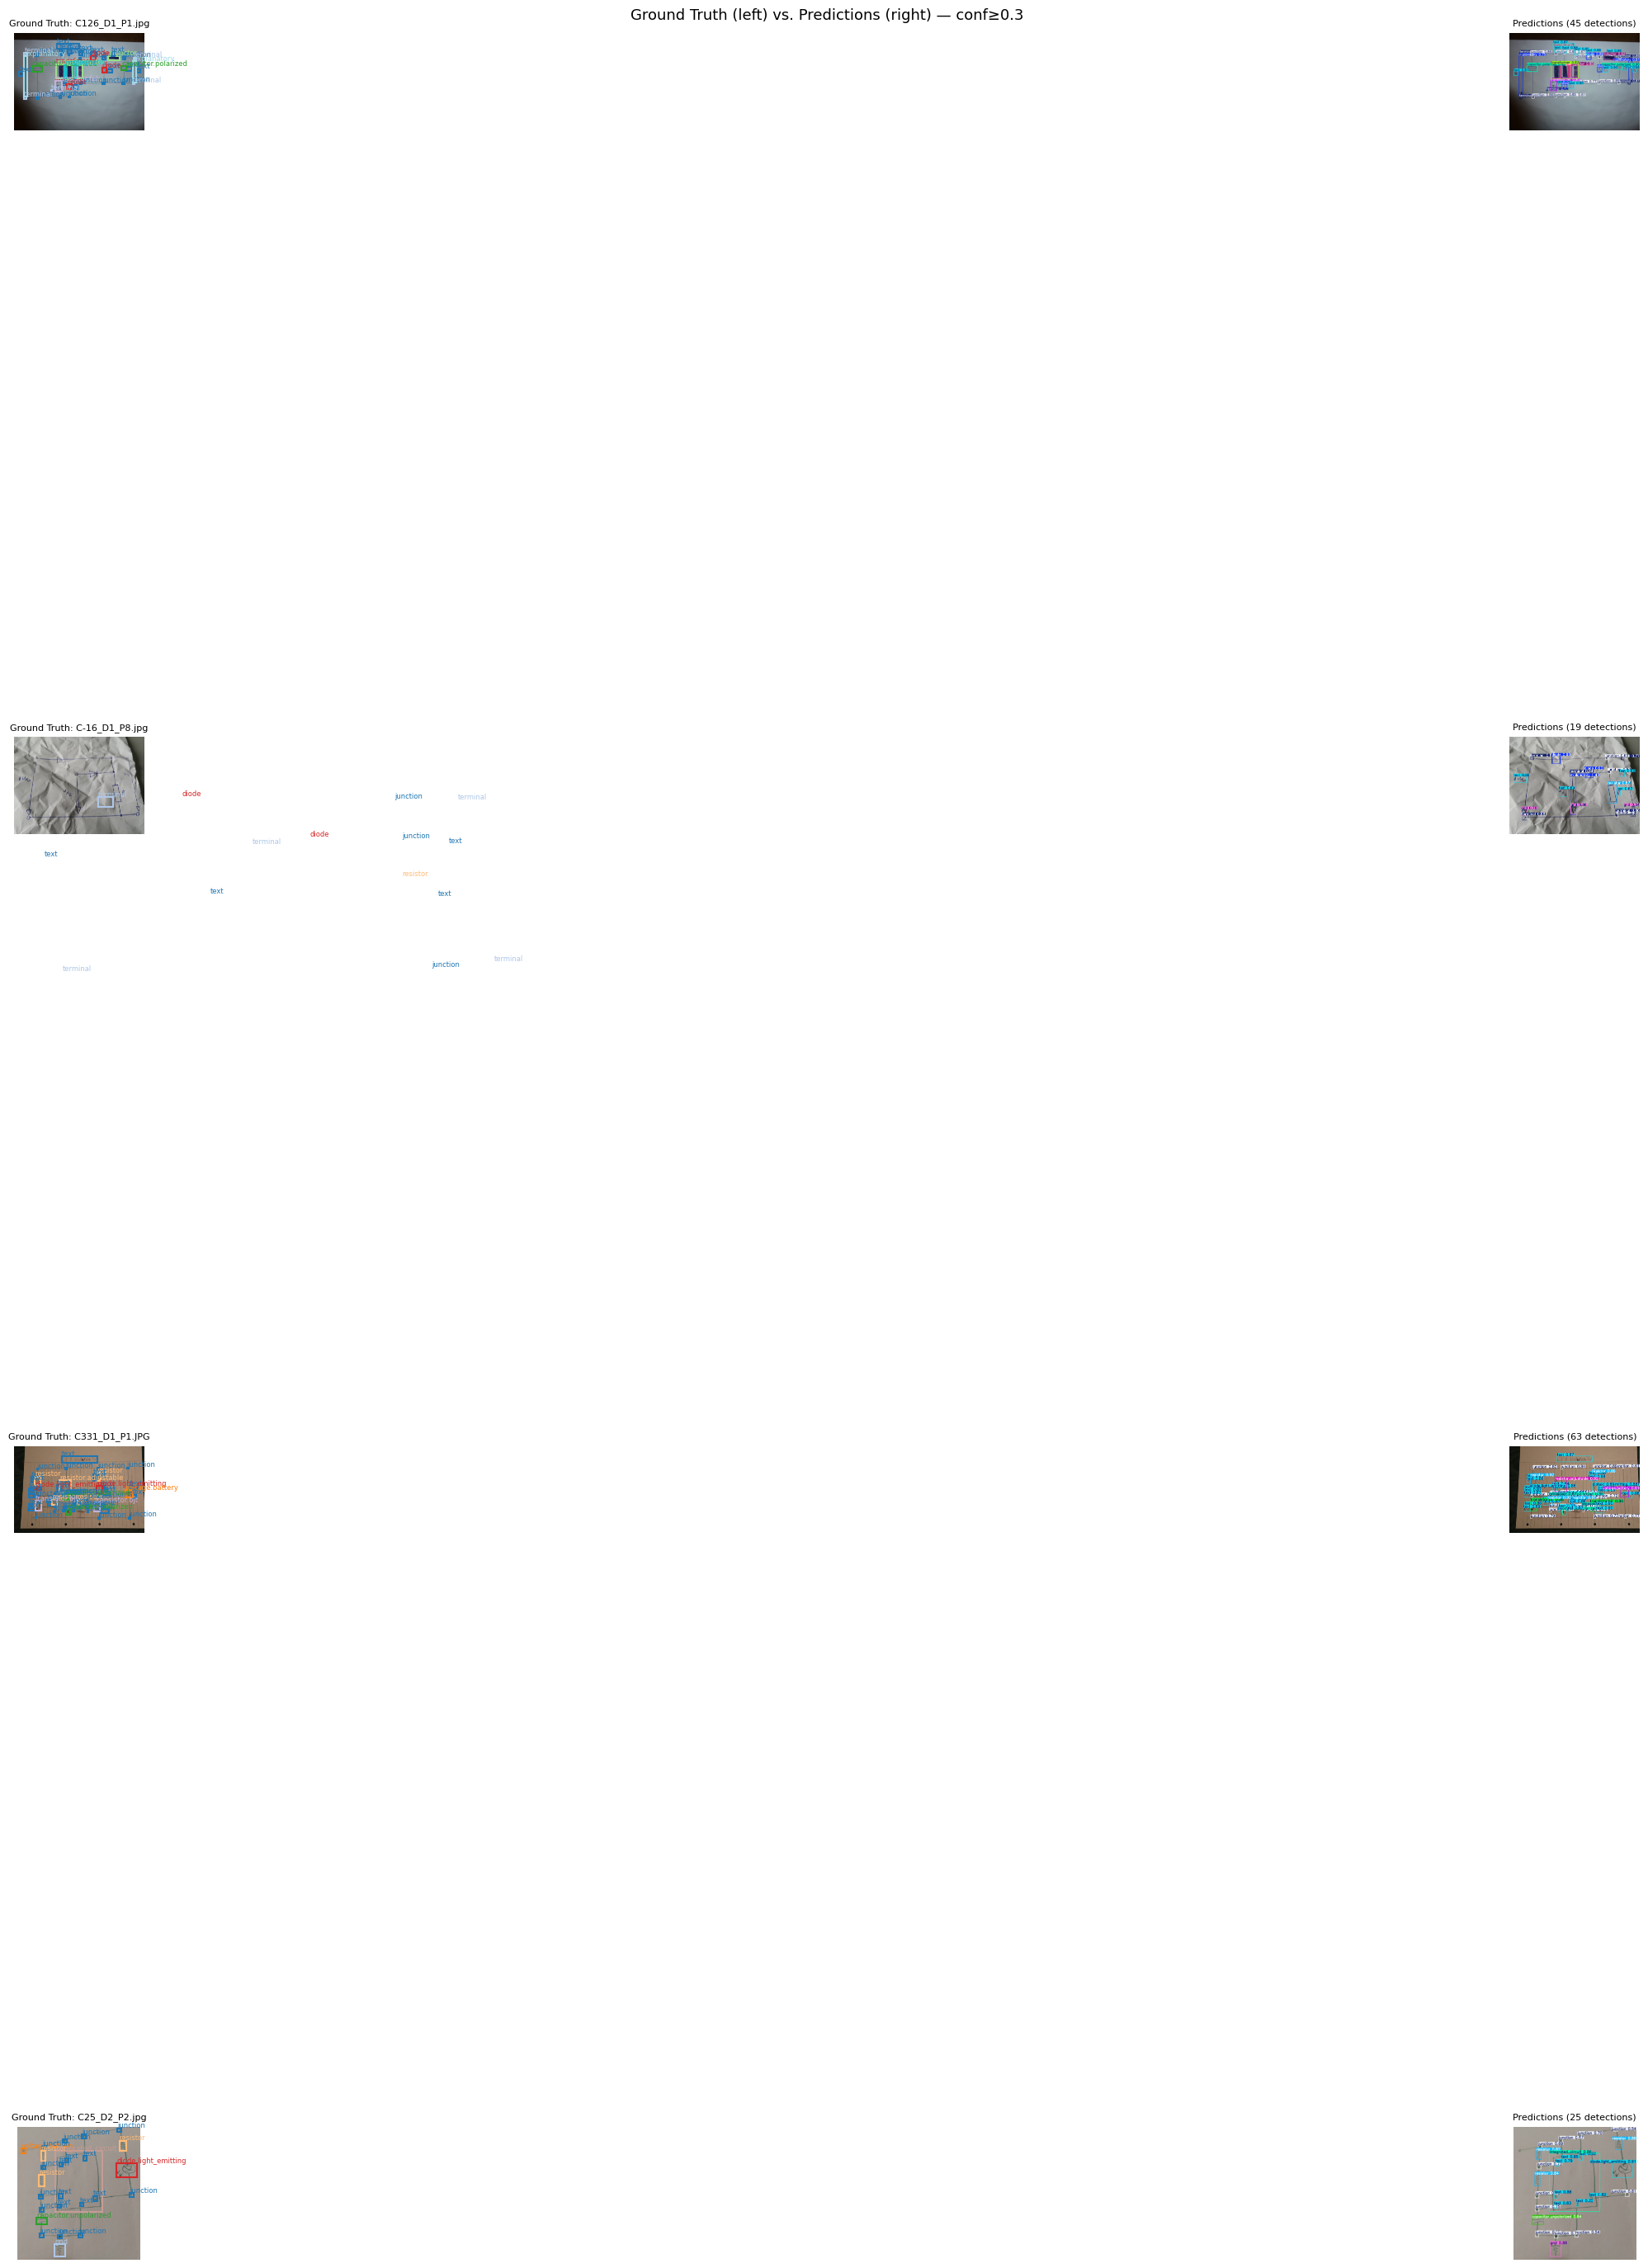

In [16]:
# ============================================================
# CELL 16: Run inference on a sample of test images and
# display side-by-side: ground truth vs. predictions
# ============================================================

CONFIDENCE_THRESHOLD = 0.30
NUMBER_OF_PREVIEW_IMAGES = 4

test_image_paths = list((YOLO_DATASET_ROOT / "images" / "test").iterdir())
preview_image_paths = random.sample(test_image_paths, min(NUMBER_OF_PREVIEW_IMAGES, len(test_image_paths)))

inference_results = evaluation_model.predict(
    source=[str(path) for path in preview_image_paths],
    conf=CONFIDENCE_THRESHOLD,
    imgsz=TRAINING_IMAGE_SIZE,
    device=0,
    verbose=False,
)

figure, axes_grid = plt.subplots(NUMBER_OF_PREVIEW_IMAGES, 2, figsize=(20, NUMBER_OF_PREVIEW_IMAGES * 7))
figure.suptitle(f"Ground Truth (left) vs. Predictions (right) — conf≥{CONFIDENCE_THRESHOLD}", fontsize=13)

for row_index, (image_path, single_result) in enumerate(zip(preview_image_paths, inference_results)):
    label_file_path = YOLO_DATASET_ROOT / "labels" / "test" / (image_path.stem + ".txt")
    loaded_image_bgr = cv2.imread(str(image_path))
    loaded_image_rgb = cv2.cvtColor(loaded_image_bgr, cv2.COLOR_BGR2RGB)
    image_height_pixels, image_width_pixels = loaded_image_rgb.shape[:2]

    ground_truth_axis = axes_grid[row_index, 0]
    ground_truth_axis.imshow(loaded_image_rgb)
    ground_truth_axis.set_title(f"Ground Truth: {image_path.name}", fontsize=8)
    ground_truth_axis.axis("off")

    if label_file_path.exists():
        with open(label_file_path, "r") as label_file:
            for label_line in label_file.read().strip().splitlines():
                label_parts = label_line.split()
                if len(label_parts) != 5:
                    continue

                class_index = int(label_parts[0])
                x_center_normalized = float(label_parts[1])
                y_center_normalized = float(label_parts[2])
                box_width_normalized = float(label_parts[3])
                box_height_normalized = float(label_parts[4])

                xmin_pixels = (x_center_normalized - box_width_normalized / 2) * image_width_pixels
                ymin_pixels = (y_center_normalized - box_height_normalized / 2) * image_height_pixels
                box_width_pixels = box_width_normalized * image_width_pixels
                box_height_pixels = box_height_normalized * image_height_pixels

                box_color = color_palette(class_index)
                ground_truth_axis.add_patch(mpl_patches.Rectangle(
                    (xmin_pixels, ymin_pixels), box_width_pixels, box_height_pixels,
                    linewidth=1.5, edgecolor=box_color, facecolor="none"
                ))

                class_label = (
                    ordered_class_name_list[class_index]
                    if class_index < len(ordered_class_name_list)
                    else str(class_index)
                )
                ground_truth_axis.text(
                    xmin_pixels, ymin_pixels - 3,
                    class_label,
                    color=box_color, fontsize=6
                )

    prediction_axis = axes_grid[row_index, 1]
    prediction_axis.imshow(single_result.plot()[:, :, ::-1])
    prediction_axis.set_title(f"Predictions ({len(single_result.boxes)} detections)", fontsize=8)
    prediction_axis.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CELL 17: Export the best model to ONNX format.
# ONNX enables fast inference independent of the PyTorch
# runtime — useful for the downstream XML generation step.
# ============================================================

export_model = YOLO(str(best_weights_path))

onnx_export_path = export_model.export(
    format="onnx",
    imgsz=TRAINING_IMAGE_SIZE,
    dynamic=True,       # allow variable batch sizes
    simplify=True,
    opset=17,
)

print(f"ONNX model exported to: {onnx_export_path}")

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 93 layers, 25,875,658 parameters, 0 gradients, 78.9 GFLOPs

PyTorch: starting from '/kaggle/working/runs/cghd_yolov8m/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 66, 8400) (49.7 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 256ms
Prepared 2 packages in 2.91s
Installed 2 packages in 10ms
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 3.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success 

In [18]:
# ============================================================
# CELL 18: Convert YOLO detections to a generic XML structure.
# This is the bridge between the object detector and your
# downstream digitization pipeline.
#
# Schema per image:
#   <schematic>
#     <component id="..." class="..." confidence="...">
#       <bounding_box xmin ymin xmax ymax />
#     </component>
#     ...
#   </schematic>
# ============================================================

import xml.dom.minidom as minidom

def convert_detections_to_xml(
    image_file_path: Path,
    yolo_inference_result,
    class_names: list[str],
    confidence_threshold: float = 0.30,
) -> str:
    """
    Convert a single YOLO inference result into a generic XML string
    representing detected electrical components in the schematic.
    """
    image_bgr = cv2.imread(str(image_file_path))
    image_height_pixels, image_width_pixels = image_bgr.shape[:2]

    root_element = xml_parser.Element("schematic")
    root_element.set("image", image_file_path.name)
    root_element.set("width", str(image_width_pixels))
    root_element.set("height", str(image_height_pixels))

    detected_boxes = yolo_inference_result.boxes

    for component_index, detection_box in enumerate(detected_boxes):
        detected_confidence = float(detection_box.conf[0])
        if detected_confidence < confidence_threshold:
            continue

        detected_class_index = int(detection_box.cls[0])
        detected_class_name = (
            class_names[detected_class_index]
            if detected_class_index < len(class_names)
            else f"class_{detected_class_index}"
        )

        xyxy_coordinates = detection_box.xyxy[0].tolist()
        xmin_absolute = int(xyxy_coordinates[0])
        ymin_absolute = int(xyxy_coordinates[1])
        xmax_absolute = int(xyxy_coordinates[2])
        ymax_absolute = int(xyxy_coordinates[3])

        component_element = xml_parser.SubElement(root_element, "component")
        component_element.set("id", str(component_index))
        component_element.set("class", detected_class_name)
        component_element.set("confidence", f"{detected_confidence:.4f}")

        bounding_box_element = xml_parser.SubElement(component_element, "bounding_box")
        bounding_box_element.set("xmin", str(xmin_absolute))
        bounding_box_element.set("ymin", str(ymin_absolute))
        bounding_box_element.set("xmax", str(xmax_absolute))
        bounding_box_element.set("ymax", str(ymax_absolute))

    raw_xml_string = xml_parser.tostring(root_element, encoding="unicode")
    prettified_xml_string = minidom.parseString(raw_xml_string).toprettyxml(indent="  ")
    return prettified_xml_string


# ── Demo: generate XML for the first test inference result ──
demo_xml_output = convert_detections_to_xml(
    preview_image_paths[0],
    inference_results[0],
    ordered_class_name_list,
    confidence_threshold=CONFIDENCE_THRESHOLD,
)

print(demo_xml_output[:1500])

<?xml version="1.0" ?>
<schematic image="C126_D1_P1.jpg" width="1296" height="972">
  <component id="0" class="transformer" confidence="0.9263">
    <bounding_box xmin="418" ymin="311" xmax="684" ymax="462"/>
  </component>
  <component id="1" class="inductor" confidence="0.9197">
    <bounding_box xmin="937" ymin="226" xmax="1050" ymax="273"/>
  </component>
  <component id="2" class="transistor.fet" confidence="0.9012">
    <bounding_box xmin="409" ymin="480" xmax="472" ymax="579"/>
  </component>
  <component id="3" class="text" confidence="0.8989">
    <bounding_box xmin="591" ymin="515" xmax="640" ymax="557"/>
  </component>
  <component id="4" class="text" confidence="0.8984">
    <bounding_box xmin="930" ymin="361" xmax="978" ymax="396"/>
  </component>
  <component id="5" class="capacitor.polarized" confidence="0.8976">
    <bounding_box xmin="1070" ymin="330" xmax="1120" ymax="368"/>
  </component>
  <component id="6" class="capacitor.polarized" confidence="0.8972">
    <bound